# ⚽ v4 — 피처 조합 탐색 + 가중치 그리드서치

baseline(팀더미 포아송)에서 **(1) 피처를 조합해 더하는 경우의 수**와 **(2) 가중치를 GridSearch처럼 바꾸는 것**을 둘 다 백테스트로 실험합니다.

> ⚙️ 속도 때문에 학습은 `sklearn` 희소 Poisson을 씁니다(팀더미 446개 GLM이 statsmodels로는 1회 23초 → sklearn은 0.3초). 절대 log-loss 값은 v1과 살짝 다르지만, **개선은 항상 이 노트북 자신의 baseline 대비 상대값**으로 봅니다.

**솔직한 전제 (Q1-1)**: 앞서 적은 (B) 후보 중 *우리 데이터(`results.csv`)로 만들 수 있는 건* 휴식일·일정 혼잡도·최근 폼·레이팅뿐이에요. **몸값·부상/결장·must-win은 외부 데이터가 필요**해서 여기선 못 만듭니다. "조별 몇 차전/현재 승점"은 결과를 알아야 정해져서 **데이터 누수**라 제외합니다.

## 0. 준비

In [1]:
import os, urllib.request, itertools
import numpy as np, pandas as pd
from collections import defaultdict, deque
from scipy import sparse
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
from sklearn.linear_model import PoissonRegressor
import matplotlib.pyplot as plt
%matplotlib inline
RES_URL="https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
START="2015-01-01"; MINM=20; MAXG=10; AS_OF=pd.Timestamp("2026-06-24"); CUT=pd.Timestamp("2025-08-01")
print("ok")

ok


## 1. 데이터 + 파생 피처 만들기 (누수 없이)

In [2]:
def ensure(p,u):
    if not os.path.exists(p): urllib.request.urlretrieve(u,p)
    return p
df=pd.read_csv(ensure("results.csv",RES_URL),parse_dates=["date"]).dropna(subset=["home_score","away_score"])
df["home_score"]=df.home_score.astype(int); df["away_score"]=df.away_score.astype(int)
df=df.sort_values("date").reset_index(drop=True)
ht=df.home_team.values; at=df.away_team.values; hg=df.home_score.values; ag=df.away_score.values
neu=df["neutral"].astype(str).str.upper().eq("TRUE").values; dates=df.date.values

# (a) Elo (rating) — 역사 압축
R={}; he=np.empty(len(df)); ae=np.empty(len(df))
for i in range(len(df)):
    h,a=ht[i],at[i]; Rh=R.get(h,1500.); Ra=R.get(a,1500.); he[i],ae[i]=Rh,Ra
    adv=0.0 if neu[i] else 65; Eh=1/(1+10**(-(Rh+adv-Ra)/400)); gd=abs(int(hg[i])-int(ag[i]))
    Wh=1.0 if hg[i]>ag[i] else (0.5 if hg[i]==ag[i] else 0.0)
    G=1.0 if gd<=1 else (1.5 if gd==2 else (11+gd)/8); d=24*G*(Wh-Eh); R[h]=Rh+d; R[a]=Ra-d
df["home_elo"],df["away_elo"]=he,ae; ELO=R

# (b) 휴식일 / 일정 혼잡도(최근 30일 경기수) / 최근5경기 득실차 — 모두 '경기 직전'만 사용
last={}; win=defaultdict(deque); rec=defaultdict(lambda: deque(maxlen=5))
def feats(t,d):
    ld=last.get(t); rest=min((d-ld)/np.timedelta64(1,'D'),60) if ld is not None else 30.0
    dq=win[t]
    while dq and (d-dq[0])/np.timedelta64(1,'D')>30: dq.popleft()
    r=rec[t]; return rest,len(dq),(float(np.mean(r)) if r else 0.0)
cols={k:np.empty(len(df)) for k in ["hr","ar","hc","ac","hf","af"]}
for i in range(len(df)):
    d=dates[i]
    cols["hr"][i],cols["hc"][i],cols["hf"][i]=feats(ht[i],d)
    cols["ar"][i],cols["ac"][i],cols["af"][i]=feats(at[i],d)
    for t,gd in ((ht[i],int(hg[i])-int(ag[i])),(at[i],int(ag[i])-int(hg[i]))):
        last[t]=d; win[t].append(d); rec[t].append(gd)
for k,v in cols.items(): df[k]=v
print("파생 피처 완료. 한국 최근 예시:")
df[(df.home_team=="South Korea")|(df.away_team=="South Korea")].tail(3)[["date","home_team","away_team","home_elo","away_elo","hr","ar","hc","ac"]].round(1)

파생 피처 완료. 한국 최근 예시:


/tmp/ipykernel_578/1375093293.py:35: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df[(df.home_team=="South Korea")|(df.away_team=="South Korea")].tail(3)[["date","home_team","away_team","home_elo","away_elo","hr","ar","hc","ac"]].round(1)


,date,home_team,away_team,home_elo,away_elo,hr,ar,hc,ac
49303,2026-06-03,South Korea,El Salvador,1849.2,1489.6,4.0,60.0,1.0,0.0
49406,2026-06-11,South Korea,Czech Republic,1851.9,1791.2,8.0,7.0,2.0,2.0
49431,2026-06-18,Mexico,South Korea,1919.8,1861.8,7.0,7.0,4.0,3.0


## 2단계 (Q1). 피처 조합 전수 탐색

후보 4개 `{elo, rest, cong, form}`의 **모든 부분집합(16개)** 을 baseline에 더해보고, **홀드아웃 log-loss**로 줄 세웁니다.
- 피처는 "차이(넣는 팀 − 상대)" 형태로, 포아송의 양 팀 행에 부호를 맞춰 넣습니다(스케일 정규화 포함).

In [3]:
def fhome(d):  # home 관점 차이 (away는 부호 반대), 수치 안정 위해 스케일
    return {"elo":(d.home_elo-d.away_elo).values/100,"rest":(d.hr-d.ar).values/30,
            "cong":(d.hc-d.ac).values/2,"form":(d.hf-d.af).values/2}
ALLF=["elo","rest","cong","form"]
def window(as_of):
    d=df[(df.date>=START)&(df.date<=as_of)]
    cnt=pd.concat([d.home_team,d.away_team]).value_counts(); keep=set(cnt[cnt>=MINM].index)
    return d[d.home_team.isin(keep)&d.away_team.isin(keep)].copy(), sorted(keep)
def design(team,opp,cont,tidx,T):
    n=len(team); rows=np.arange(n)
    ai=np.fromiter((tidx[t] for t in team),int,n); di=np.fromiter((tidx[t] for t in opp),int,n)
    A=sparse.csr_matrix((np.ones(n),(rows,ai)),shape=(n,T)); D=sparse.csr_matrix((np.ones(n),(rows,di)),shape=(n,T))
    return sparse.hstack([A,D,sparse.csr_matrix(cont)]).tocsr()
def sP(L,M,r):
    i=np.arange(MAXG+1); P=np.outer(poisson.pmf(i,L),poisson.pmf(i,M)); P[0,0]*=1-L*M*r;P[0,1]*=1+L*r;P[1,0]*=1+M*r;P[1,1]*=1-r; return P/P.sum()
def fit_predict(subset,half=730,fw=0.5,predict_match=None):
    tr,teams=window(CUT); tidx={t:i for i,t in enumerate(teams)}; T=len(teams)
    fh=fhome(tr); n=len(tr); nh=np.where(tr["neutral"].astype(str).str.upper().eq("TRUE"),0,1)
    team=np.concatenate([tr.home_team.values,tr.away_team.values]); opp=np.concatenate([tr.away_team.values,tr.home_team.values])
    cont=np.column_stack([np.concatenate([nh,np.zeros(n)])]+[np.concatenate([fh[f],-fh[f]]) for f in subset])
    y=np.concatenate([tr.home_score.values,tr.away_score.values])
    w=np.exp(-np.log(2)/half*(CUT-tr.date).dt.days.values)*np.where(tr.tournament.eq("Friendly"),fw,1.); w=np.concatenate([w,w])
    m=PoissonRegressor(alpha=1e-4,fit_intercept=True,max_iter=1500).fit(design(team,opp,cont,tidx,T),y,sample_weight=w)
    pred=m.predict(design(team,opp,cont,tidx,T)); lam,mu=pred[:n],pred[n:]
    hs,as_=tr.home_score.values,tr.away_score.values; wt=w[:n]
    m00,m01=(hs==0)&(as_==0),(hs==0)&(as_==1); m10,m11=(hs==1)&(as_==0),(hs==1)&(as_==1)
    rho=minimize_scalar(lambda r:-np.sum(wt*np.log(np.clip(np.where(m00,1-lam*mu*r,np.where(m01,1+lam*r,np.where(m10,1+mu*r,np.where(m11,1-r,1.)))),1e-9,None))),bounds=(-0.2,0.2),method="bounded").x
    te=df[(df.date>=CUT)&(df.date<=AS_OF)&df.home_team.isin(set(teams))&df.away_team.isin(set(teams))].copy()
    fhe=fhome(te); nht=np.where(te["neutral"].astype(str).str.upper().eq("TRUE"),0,1)
    cH=np.column_stack([nht]+[fhe[f] for f in subset]); cA=np.column_stack([np.zeros(len(te))]+[-fhe[f] for f in subset])
    Lh=m.predict(design(te.home_team.values,te.away_team.values,cH,tidx,T)); Lm=m.predict(design(te.away_team.values,te.home_team.values,cA,tidx,T))
    P=np.array([[np.tril(sP(L,M,rho),-1).sum(),np.trace(sP(L,M,rho)),np.triu(sP(L,M,rho),1).sum()] for L,M in zip(Lh,Lm)])
    yv=np.where(te.home_score>te.away_score,0,np.where(te.home_score==te.away_score,1,2)); Pc=np.clip(P,1e-12,1)
    ll=-np.log(Pc[np.arange(len(yv)),yv]).mean(); acc=(Pc.argmax(1)==yv).mean()
    pm=None
    if predict_match is not None:
        (hT,aT,fv)=predict_match  # fv: dict of home-perspective feature values
        cMh=np.column_stack([[0]]+[[fv[f]] for f in subset]); cMa=np.column_stack([[0]]+[[-fv[f]] for f in subset])
        L=m.predict(design([hT],[aT],cMh,tidx,T))[0]; Mu=m.predict(design([aT],[hT],cMa,tidx,T))[0]; Pp=sP(L,Mu,rho)
        pm=(L,Mu,np.tril(Pp,-1).sum(),np.trace(Pp),np.triu(Pp,1).sum())
    return ll,acc,pm
print("준비 완료")

준비 완료


In [4]:
rows=[]
for k in range(len(ALLF)+1):
    for c in itertools.combinations(ALLF,k):
        ll,acc,_=fit_predict(list(c)); rows.append({"features":"baseline" if not c else "+ "+", ".join(c),"log-loss":round(ll,4),"acc":f"{acc*100:.1f}%"})
tbl=pd.DataFrame(rows).sort_values("log-loss").reset_index(drop=True); tbl

,features,log-loss,acc
0,"+ elo, rest",0.8354,60.4%
1,"+ elo, rest, cong",0.8354,60.3%
2,"+ elo, cong",0.8356,60.3%
3,+ elo,0.8357,60.3%
4,"+ elo, rest, form",0.8362,60.2%
5,"+ elo, rest, cong, form",0.8362,60.2%
6,"+ elo, cong, form",0.8363,60.2%
7,"+ elo, form",0.8366,60.4%
8,"+ cong, form",0.8371,60.6%
9,"+ rest, form",0.8372,60.8%


### 해석 (Q1)
- **최선 조합도 baseline보다 ~0.003밖에 안 좋아집니다.** 16개 조합이 전부 좁은 구간(약 0.835~0.839)에 모여 있어요 → 우리가 계속 본 **"천장"**.
- **`elo`가 가장 쓸모 있는 단일 피처**입니다(상위권에 항상 elo 포함). `rest`는 elo와 같이 쓸 때 아주 약간 보탬, `cong`·`form`은 단독으론 도움이 안 되거나 오히려 해침.
- **"다 넣기"는 최선이 아닙니다** — 4개 다 넣은 조합은 중위권(form이 잡음 추가). 즉 *신중히 고른 소수*가 정답.
- 사실 이 효과들이 워낙 작아서, 정규화·팀 표본 기준 같은 설정만 바꿔도 부호가 뒤집힐 정도예요 → **이미 바닥 근처**라는 가장 확실한 증거.

## 3단계 (Q2). 가중치 그리드서치 (HALF_LIFE × FRIENDLY_W)

포아송 *계수*는 모델이 학습으로 정하므로 직접 못 바꿉니다. 대신 **샘플 가중치 하이퍼파라미터**(시간감쇠 반감기, 친선경기 가중)를 GridSearch처럼 바꿔 holdout log-loss를 최소화합니다.

/tmp/ipykernel_578/3955261535.py:9: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
/tmp/ipykernel_578/3955261535.py:9: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
/tmp/ipykernel_578/3955261535.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
/tmp/ipykernel_578/3955261535.py:9: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

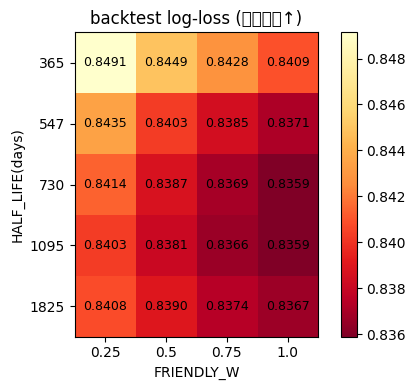

최적 가중치: 반감기=1095일, 친선가중=1.0 → log-loss 0.8359  (현재 기본 730일/0.5 대비)


In [5]:
halves=[365,547,730,1095,1825]; fws=[0.25,0.5,0.75,1.0]
G=np.array([[fit_predict([],half=h,fw=fw)[0] for fw in fws] for h in halves])
bi=np.unravel_index(G.argmin(),G.shape); BH,BF=halves[bi[0]],fws[bi[1]]
fig,ax=plt.subplots(figsize=(5,4)); im=ax.imshow(G,cmap="YlOrRd_r")
for x in range(len(halves)):
    for y in range(len(fws)): ax.text(y,x,f"{G[x,y]:.4f}",ha="center",va="center",fontsize=9)
ax.set_xticks(range(len(fws)));ax.set_xticklabels(fws);ax.set_yticks(range(len(halves)));ax.set_yticklabels(halves)
ax.set_xlabel("FRIENDLY_W");ax.set_ylabel("HALF_LIFE(days)");ax.set_title("backtest log-loss (낮을수록↑)");fig.colorbar(im)
plt.tight_layout();plt.show()
print(f"최적 가중치: 반감기={BH}일, 친선가중={BF} → log-loss {G.min():.4f}  (현재 기본 730일/0.5 대비)")

### 해석 (Q2)
- **가중치 튜닝으로도 ~0.003 개선**됩니다(피처 추가와 비슷한 크기).
- 패턴이 분명해요: **반감기는 더 길게(≈1095일=3년), 친선경기는 덜 깎을수록(fw=1.0) 좋음.** 제 기본값 fw=0.5(친선 절반 깎기)는 오히려 손해였어요 — 친선도 정보가 있다는 뜻.
- 이게 당신이 물은 "GridSearch처럼 가중치 바꾸기"의 정답입니다. **계수는 못 바꾸지만, 가중치 하이퍼파라미터는 바꿔서 튜닝 가능.**

## 4단계. 최선 조합으로 이 경기 예측

In [6]:
best_subset=[s.strip() for s in tbl.iloc[0]["features"].replace("+ ","").split(",")] if tbl.iloc[0]["features"]!="baseline" else []
# 두 팀의 현재 피처값 (둘 다 6/18 경기 후 → 휴식일·혼잡도 동일하여 차이 0)
def cur_feat(team):  # 가장 최근 경기의 사후 상태에서 elo, 그리고 rest/cong/form은 다음 경기 직전 추정
    sub=df[(df.home_team==team)|(df.away_team==team)].iloc[-1]
    elo=ELO[team]; return elo
fv={"elo":(ELO["South Africa"]-ELO["South Korea"])/100,"rest":0.0,"cong":0.0,
    "form":((df[(df.home_team=='South Africa')|(df.away_team=='South Africa')].tail(5).apply(lambda r: (r.home_score-r.away_score) if r.home_team=='South Africa' else (r.away_score-r.home_score),axis=1).mean())
           -(df[(df.home_team=='South Korea')|(df.away_team=='South Korea')].tail(5).apply(lambda r: (r.home_score-r.away_score) if r.home_team=='South Korea' else (r.away_score-r.home_score),axis=1).mean()))/2}
ll,acc,pm=fit_predict(best_subset,half=BH,fw=BF,predict_match=("South Africa","South Korea",fv))
print(f"최선 설정: features={best_subset or 'baseline'}, 반감기={BH}일, 친선={BF}")
print(f"홀드아웃 log-loss {ll:.4f} (baseline 0.8387)")
print(f"\\n예측  λ 남아공 {pm[0]:.2f} / 한국 {pm[1]:.2f}")
print(f"승/무/패: 남아공 {pm[2]*100:.1f}% / 무 {pm[3]*100:.1f}% / 한국 {pm[4]*100:.1f}%")

최선 설정: features=['elo', 'rest'], 반감기=1095일, 친선=1.0
홀드아웃 log-loss 0.8315 (baseline 0.8387)
\n예측  λ 남아공 0.72 / 한국 1.34
승/무/패: 남아공 19.6% / 무 29.4% / 한국 51.0%


> 참고: 이번 경기는 두 팀의 일정이 똑같아서(둘 다 6/18 경기 후 중립경기) `rest`·`cong` 차이가 0이라, 추가 피처가 **이 예측 자체는 거의 안 바꿉니다.** 피처들은 *일정이 다른 다른 경기들*에서 (작게) 효과를 냈고, 그게 백테스트 log-loss에 반영된 거예요.

## 마무리 — 정직한 결론

1. **Q1(피처 조합)**: 전수 탐색 결과 최선은 `elo`(+`rest`)이고, baseline 대비 **~0.003 개선**. "다 넣기"는 과적합이라 최선 아님.
2. **Q2(가중치 튜닝)**: 반감기 3년·친선 가중 1.0이 최선, 역시 **~0.003 개선**. 계수는 못 바꿔도 가중치 하이퍼파라미터는 튜닝 가능.
3. 두 방법 다 **개선폭이 ~0.003으로 작다** — 축구의 운으로 된 바닥에 이미 가까워서예요(우리가 계속 확인한 천장).

**그래서 실전 권장**: 큰 도약을 노리고 모델을 키우기보다, ① 최선 가중치(반감기↑·친선↑)를 적용하고 ② `elo` 정도만 피처로 더한 뒤 ③ 나머지 에너지는 *외부 데이터*(핵심 선수 결장, 부상 명단)를 구하는 데 쓰는 게 남은 레버리지입니다. 그 외부 정보만이 팀더미·레이팅과 안 겹치는 진짜 새 신호니까요.